c:\Users\ASUS\anaconda3\envs\myenv2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 Loading Local YAMNet...
 YAMNet Loaded Successfully!

Embedding test: (1024,)
Classes: ['car_crash', 'conversation', 'engine_idling', 'gun_shot', 'jambret', 'maling', 'rain', 'rampok', 'road_traffic', 'scream', 'thunderstorm', 'tolong', 'wind']
Total audio files: 1678

 Extracting / Loading embeddings...


100%|██████████| 1678/1678 [00:20<00:00, 80.18it/s]



Feature shape: (1678, 1024) Labels: 1678

Training classifier: rf
Model Saved → C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\SLIIT\Y4 S1\RP\project\ML\embeddings

 Classification Report:
                precision    recall  f1-score   support

    car_crash       0.75      0.79      0.77        19
 conversation       0.94      0.94      0.94        16
engine_idling       0.92      0.85      0.88        13
     gun_shot       0.93      1.00      0.96        38
      jambret       0.81      0.88      0.85        34
       maling       0.82      0.82      0.82        34
         rain       0.94      0.85      0.89        20
       rampok       0.89      0.91      0.90        34
 road_traffic       0.92      0.92      0.92        24
       scream       0.96      0.90      0.93        30
 thunderstorm       0.95      0.95      0.95        20
       tolong       0.83      0.71      0.76        34
         wind       0.86      0.95      0.90        20

     

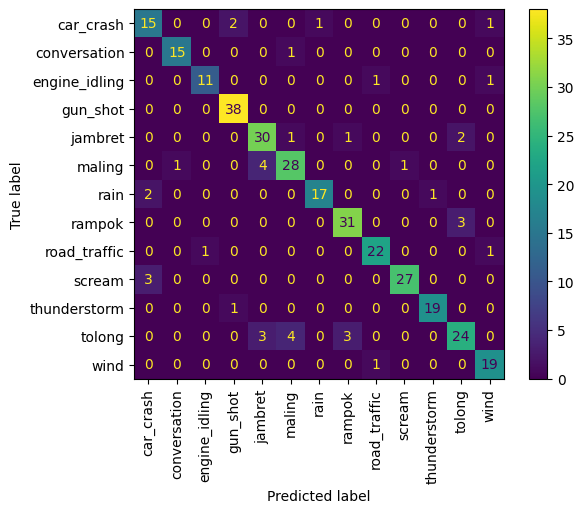


 TEST RESULT → road_traffic (0.74)


In [3]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import librosa
import joblib
import soundfile as sf

import tensorflow as tf
from tensorflow.keras import Model, layers   # ensure keras loads properly

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


# ================== USER SETTINGS ==================
DATA_DIR = r"C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\SLIIT\Y4 S1\RP\project\ML\dataset"
EMBED_DIR = r"C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\SLIIT\Y4 S1\RP\project\ML\embeddings"
TEST_WAV = r"C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\SLIIT\Y4 S1\RP\project\ML\dataset\road_traffic\road (2).wav"

YAMNET_SR = 16000
AGG_METHOD = "mean"   # mean / max / mean+std
CLASSIFIER = "rf"     # rf / logreg
TEST_SIZE = 0.2
RANDOM_SEED = 42
# ===================================================

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(EMBED_DIR, exist_ok=True)

# ---------- LOAD LOCAL YAMNET ----------
print("\n Loading Local YAMNet...")
import sys
sys.path.append("yamnet")

from yamnet import yamnet_frames_model
from params import Params

params = Params()
yamnet_model = yamnet_frames_model(params)
yamnet_model.load_weights("yamnet/yamnet.h5")

yamnet_model(tf.zeros([16000], dtype=tf.float32))  # warmup
print(" YAMNet Loaded Successfully!\n")


# ---------- EMBEDDING EXTRACTION ----------
def extract_yamnet_embedding_for_waveform(y, agg="mean"):
    waveform = tf.convert_to_tensor(y, dtype=tf.float32)
    scores, embeddings, spectrogram = yamnet_model(waveform)
    emb = embeddings.numpy()

    if agg == "mean": return emb.mean(axis=0)
    if agg == "max": return emb.max(axis=0)
    if agg == "mean+std": return np.concatenate([emb.mean(axis=0), emb.std(axis=0)])
    return emb.mean(axis=0)


# Test
print("Embedding test:", extract_yamnet_embedding_for_waveform(np.zeros(YAMNET_SR)).shape)


# ---------- LOAD DATASET ----------
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
filepaths, labels = [], []

for c in classes:
    for f in os.listdir(os.path.join(DATA_DIR,c)):
        if f.lower().endswith((".wav",".mp3",".ogg",".flac")):
            filepaths.append(os.path.join(DATA_DIR,c,f))
            labels.append(c)

print("Classes:", classes)
print("Total audio files:", len(filepaths))


# ---------- CACHE EMBEDDINGS ----------
def embed_path(fp): return os.path.join(EMBED_DIR, os.path.splitext(os.path.basename(fp))[0]+".npy")

meta=[]
print("\n Extracting / Loading embeddings...")
for fp,lab in tqdm(zip(filepaths,labels), total=len(filepaths)):
    p=embed_path(fp)
    if os.path.exists(p): emb=np.load(p)
    else:
        audio,_ = librosa.load(fp, sr=YAMNET_SR, mono=True)
        emb=extract_yamnet_embedding_for_waveform(audio, agg=AGG_METHOD)
        np.save(p,emb)
    meta.append((fp,lab,p))

# Build X,y
X,y=[],[]
for fp,lab,p in meta:
    X.append(np.load(p))
    y.append(lab)

X=np.array(X); y=np.array(y)

print("\nFeature shape:",X.shape,"Labels:",len(y))


# ---------- ENCODING + SCALING ----------
le=LabelEncoder()
y_enc = le.fit_transform(y)
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)


# ---------- TRAIN MODEL ----------
x_train,x_val,y_train,y_val = train_test_split(X_scaled,y_enc,test_size=TEST_SIZE,
                                               stratify=y_enc,random_state=RANDOM_SEED)

print("\nTraining classifier:",CLASSIFIER)

if CLASSIFIER=="rf":
    clf=RandomForestClassifier(n_estimators=300,max_depth=20,class_weight="balanced",n_jobs=-1)
else:
    clf=LogisticRegression(max_iter=2000,solver="saga",class_weight="balanced")

clf.fit(x_train,y_train)
joblib.dump({"clf":clf,"scaler":scaler,"le":le}, os.path.join(EMBED_DIR,"clf_pipeline.joblib"))

print("Model Saved →", EMBED_DIR)


# ---------- EVALUATE ----------
pred=clf.predict(x_val)
print("\n Classification Report:\n",classification_report(y_val,pred,target_names=le.classes_))


# ---------- CONFUSION MATRIX ----------
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_val,pred,display_labels=le.classes_,xticks_rotation=90)
plt.show()


# ---------- INFERENCE ----------
def predict_file(clf_pipe,fp,w=1.5,h=0.75,agg=AGG_METHOD):
    clf=scaler=le=None
    clf=clf_pipe["clf"]; scaler=clf_pipe["scaler"]; le=clf_pipe["le"]

    audio,_=librosa.load(fp,sr=YAMNET_SR)
    win,hop=int(w*YAMNET_SR),int(h*YAMNET_SR)
    probs=[]

    for i in range(0,max(1,len(audio)-win+1),hop):
        seg=audio[i:i+win]
        if len(seg)<win: seg=np.pad(seg,(0,win-len(seg)))
        emb=extract_yamnet_embedding_for_waveform(seg,agg)
        p=clf.predict_proba(scaler.transform([emb]))[0]
        probs.append(p)

    avg=np.mean(probs,axis=0)
    return le.inverse_transform([avg.argmax()])[0], avg.max()


pipe=joblib.load(os.path.join(EMBED_DIR,"clf_pipeline.joblib"))
if os.path.exists(TEST_WAV):
    label,p=predict_file(pipe,TEST_WAV)
    print(f"\n TEST RESULT → {label} ({p:.2f})")
else:
    print("Set TEST_WAV path!")


#### INFERANCE

In [1]:
# ----------- Standalone Inference Script for YAMNet Classification -----------

import numpy as np
import librosa
import joblib
import tensorflow as tf
import tensorflow_hub as hub
import sys
sys.path.append("yamnet")  # folder path
from yamnet import yamnet_frames_model
from params import Params


# ===== USER INPUT =====
AUDIO_PATH = r"C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\SLIIT\Y4 S1\RP\project\ML\dataset\wind\wind (3).wav"
PIPELINE_PATH = r"embeddings/clf_pipeline.joblib"   # saved earlier
AGG_METHOD = "mean"        # or: "max", "mean+std"
WINDOW_S = 1.5
HOP_S = 0.75
YAMNET_SR = 16000          # YAMNet required sample rate
# =======================

# -------- Load classifier pipeline --------
pipe = joblib.load(PIPELINE_PATH)
clf = pipe["clf"]
scaler = pipe["scaler"]
le = pipe["le"]

# -------- Load YAMNet model --------
print("Loading YAMNet local weight model...")

yamnet_params = Params()
yamnet_model = yamnet_frames_model(yamnet_params)
yamnet_model.load_weights("yamnet/yamnet.h5")  # path to weights

# Warmup forward pass required once (important)
_ = yamnet_model(tf.zeros([16000], dtype=tf.float32))

print("YAMNet Loaded Successfully (Local)")


# -------- Helper: YAMNet embedding extraction --------
def extract_yamnet_embedding_for_waveform(y, agg="mean"):
    scores, embeddings, log_mel = yamnet_model(tf.convert_to_tensor(y, dtype=tf.float32))
    emb = embeddings.numpy()  # shape: (frames, 1024)

    if agg == "mean":
        return emb.mean(axis=0)
    elif agg == "max":
        return emb.max(axis=0)
    elif agg == "mean+std":
        return np.concatenate([emb.mean(axis=0), emb.std(axis=0)])
    else:
        return emb.mean(axis=0)

# -------- Sliding-window inference --------
def classify_audio(audio_path):
    y, sr = librosa.load(audio_path, sr=YAMNET_SR, mono=True)

    win = int(WINDOW_S * sr)
    hop = int(HOP_S * sr)

    probs = []

    for start in range(0, max(1, len(y) - win + 1), hop):
        seg = y[start:start+win]
        if len(seg) < win:
            seg = np.pad(seg, (0, win - len(seg)), mode='constant')

        # extract embedding
        emb = extract_yamnet_embedding_for_waveform(seg, agg=AGG_METHOD)

        # scale + predict
        emb_scaled = scaler.transform(emb.reshape(1, -1))
        p = clf.predict_proba(emb_scaled)[0]
        probs.append(p)

    # average window predictions
    final_prob = np.mean(probs, axis=0)
    idx = np.argmax(final_prob)
    predicted_label = le.inverse_transform([idx])[0]

    return predicted_label, float(final_prob[idx]), final_prob, list(le.classes_)

# -------- Run inference --------
label, prob, raw_probs, class_list = classify_audio(AUDIO_PATH)

print("--------------- RESULT ----------------")
print("Audio:", AUDIO_PATH)
print("Predicted Class:", label)
print("Confidence:", prob)
print("---------------------------------------")


Loading YAMNet local weight model...
YAMNet Loaded Successfully (Local)
--------------- RESULT ----------------
Audio: C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\SLIIT\Y4 S1\RP\project\ML\dataset\wind\wind (3).wav
Predicted Class: wind
Confidence: 0.35333333333333333
---------------------------------------
